# Module Project: Regression analysis on a WEATHER-dataset

In this project, we will use the concepts of regression and regularization to predict future weather conditions based on temperature, humidity, and pressure. We shall apply linear regression, polynomial regression, and ridge regression to obtain accurate weather predictions. Additionally, we will experiment with hyperparameters to improve model performance and achieve better forecasting results.

# Data Analysis

### 1.Loading data from file "Dailyweather" into a Dataframe



In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'/content/Dailyweather.csv'
df = pd.read_csv(file_path)

print(df.sample(10))




            date   meantemp   humidity  wind_speed  meanpressure weather
340   2013-12-07  16.000000  80.500000    1.162500   1014.250000  Normal
518   2014-06-03  34.875000  33.625000    6.487500   1000.000000  Normal
216   2013-08-05  29.500000  77.000000    6.783333   1001.000000   Rainy
597   2014-08-21  32.500000  43.000000   10.887500   1001.250000  Normal
680   2014-11-12  19.625000  52.000000    2.312500   1015.875000  Normal
1131  2016-02-06  15.333333  69.500000    3.700000   1013.333333  Normal
36    2013-02-06  16.666667  71.333333    8.633333   1018.666667   Rainy
454   2014-03-31  24.125000  44.125000   13.200000   1008.250000  Normal
157   2013-06-07  34.000000  49.250000    7.412500    998.000000  Normal
826   2015-04-07  23.750000  62.125000    9.737500   1010.250000  Cloudy


### 2. Creating a new DataFrame that calculates the cumulative average of temperature, humidity, and pressure for each date to analyze long-term weather trends.

In [26]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(by="date")

df["cumulative_avg_temp"] = df["meantemp"].expanding().mean()
df["cumulative_avg_humidity"] = df["humidity"].expanding().mean()
df["cumulative_avg_pressure"] = df["meanpressure"].expanding().mean()

cumulative_df = df[["date", "cumulative_avg_temp", "cumulative_avg_humidity", "cumulative_avg_pressure"]]

cumulative_df.to_csv("cumulative_weather_data.csv", index=False)

print(cumulative_df.sample(10))

           date  cumulative_avg_temp  cumulative_avg_humidity  \
102  2013-04-13            18.579901                63.150277   
241  2013-08-30            25.949429                59.442542   
591  2014-08-15            25.153845                61.453414   
320  2013-11-17            25.965943                61.450148   
1119 2016-01-25            24.739155                61.803266   
191  2013-07-11            24.943781                54.758526   
978  2015-09-06            25.224455                61.124006   
1205 2016-04-20            24.717111                61.208419   
791  2015-03-03            24.178082                62.271147   
802  2015-03-14            24.109484                62.334681   

      cumulative_avg_pressure  
102               1014.144475  
241               1005.790840  
591               1007.391351  
320               1006.529818  
1119              1008.478572  
191               1007.526873  
978               1007.757074  
1205              1014.28253

### 3.Creating a new column in the DataFrame called "average weather ", which represents a combined metric based on temperature, humidity, and pressure to analyze overall weather trends.

In [27]:
df["average_weather"] = (df["meantemp"] + df["humidity"] + df["meanpressure"]) / 3

cumulative_df = df[["date", "cumulative_avg_temp", "cumulative_avg_humidity", "cumulative_avg_pressure", "average_weather"]]

cumulative_df.to_csv("cumulative_weather_data.csv", index=False)

print(cumulative_df.sample(10))


           date  cumulative_avg_temp  cumulative_avg_humidity  \
831  2015-04-12            24.122881                62.342632   
1411 2016-11-12            25.718655                60.680792   
1457 2016-12-28            25.528165                60.688411   
407  2014-02-12            23.658561                64.867481   
727  2014-12-29            24.936526                61.386601   
369  2014-01-05            24.624379                63.329450   
554  2014-07-09            24.730634                61.139237   
439  2014-03-16            23.220000                65.330609   
1026 2015-10-24            25.406829                60.966566   
515  2014-05-31            24.013386                62.272951   

      cumulative_avg_pressure  average_weather  
831               1008.860142       366.583333  
1411              1011.416100       365.576923  
1457              1011.089121       366.942029  
407               1008.657257       364.583333  
727               1007.973363       367

### 4.Creating a new column in the DataFrame called "weather variability", which represents fluctuations in temperature, humidity, and pressure to analyze changing weather patterns.

In [28]:
df["weather_variability"] = df[["meantemp", "humidity", "meanpressure"]].std(axis=1)

cumulative_df = df[["date", "cumulative_avg_temp", "cumulative_avg_humidity", "cumulative_avg_pressure", "average_weather", "weather_variability"]]

cumulative_df.to_csv("cumulative_weather_data.csv", index=False)

print(cumulative_df.sample(10))


           date  cumulative_avg_temp  cumulative_avg_humidity  \
239  2013-08-28            25.912897                59.396230   
470  2014-04-16            23.372793                64.341720   
431  2014-03-08            23.265534                65.377530   
109  2013-04-20            19.279556                61.132955   
1458 2016-12-29            25.521113                60.707033   
1051 2015-11-18            25.338225                61.027247   
552  2014-07-07            24.691685                61.221793   
1199 2016-04-14            24.668475                61.378968   
92   2013-04-03            17.533244                66.668894   
161  2013-06-11            23.723773                52.734619   

      cumulative_avg_pressure  average_weather  weather_variability  
239               1005.810972       364.857143           553.477633  
470               1009.203480       363.000000           558.959958  
431               1009.056010       366.916667           563.418366  
109 

### 5.Plotting the daily average temperature, humidity, and pressure over time and summarize the observed weather trends.

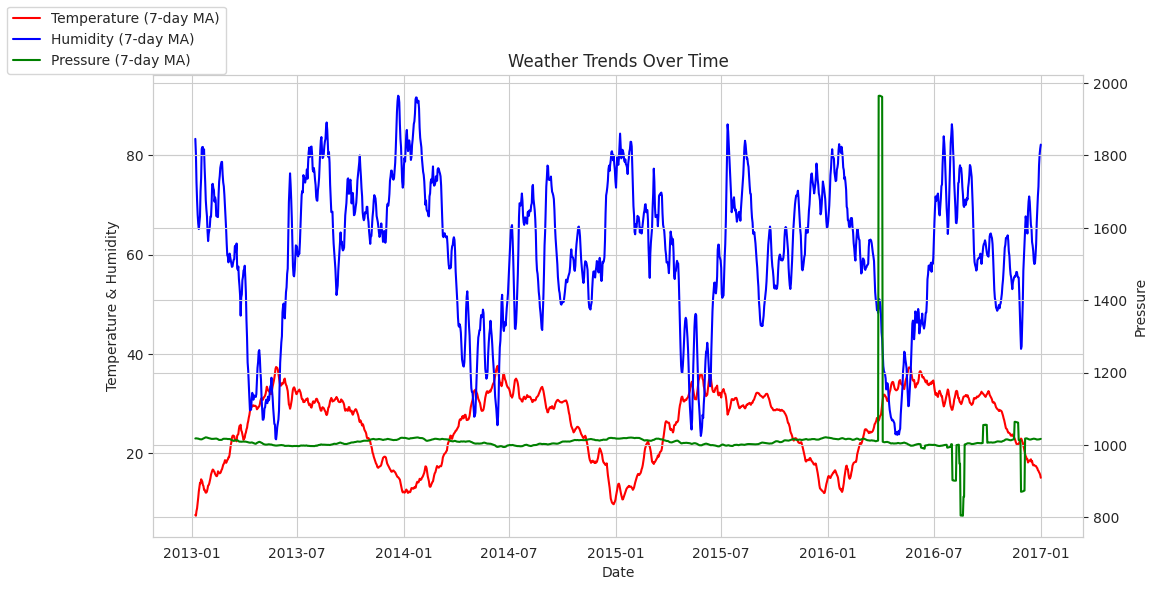

In [29]:
df['temp_MA7'] = df['meantemp'].rolling(window=7).mean()
df['humidity_MA7'] = df['humidity'].rolling(window=7).mean()
df['pressure_MA7'] = df['meanpressure'].rolling(window=7).mean()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature & Humidity")
ax1.plot(df["date"], df["temp_MA7"], color='red', label="Temperature (7-day MA)")
ax1.plot(df["date"], df["humidity_MA7"], color='blue', label="Humidity (7-day MA)")
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.set_ylabel("Pressure")
ax2.plot(df["date"], df["pressure_MA7"], color='green', label="Pressure (7-day MA)")

fig.legend(loc="upper left")
plt.title("Weather Trends Over Time")
plt.show()

### 6.Creating a single plot showing the trend of temparature, humidity, and pressure over time to analyze weather patterns

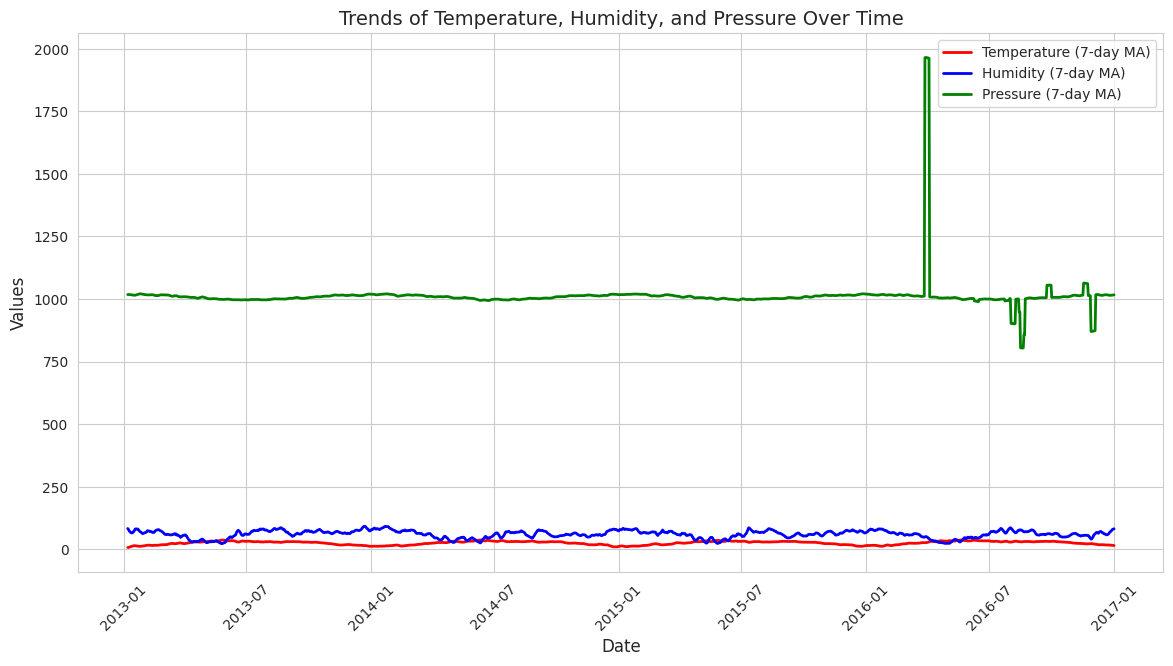

        date  cumulative_avg_temp  cumulative_avg_humidity  \
0 2013-01-01            10.000000                84.500000   
1 2013-01-02             8.700000                88.250000   
2 2013-01-03             8.188889                87.833333   
3 2013-01-04             8.308333                83.708333   
4 2013-01-05             7.846667                84.333333   

   cumulative_avg_pressure  average_weather_index  weather_variability  
0              1015.666667             370.055556           560.355104  
1              1016.733333             372.400000           560.531141  
2              1017.377778             370.944444           562.362337  
3              1017.325000             365.722222           565.036880  
4              1017.160000             369.777778           561.534266  


In [30]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(by="date")

df["cumulative_avg_temp"] = df["meantemp"].expanding().mean()
df["cumulative_avg_humidity"] = df["humidity"].expanding().mean()
df["cumulative_avg_pressure"] = df["meanpressure"].expanding().mean()

df["average_weather_index"] = (df["meantemp"] + df["humidity"] + df["meanpressure"]) / 3

df["weather_variability"] = df[["meantemp", "humidity", "meanpressure"]].std(axis=1)

cumulative_df = df[["date", "cumulative_avg_temp", "cumulative_avg_humidity", "cumulative_avg_pressure", "average_weather_index", "weather_variability"]]

cumulative_df.to_csv("cumulative_weather_data.csv", index=False)

plt.figure(figsize=(14,7))
sns.set_style("whitegrid")

df["temp_MA7"] = df["meantemp"].rolling(window=7).mean()
df["humidity_MA7"] = df["humidity"].rolling(window=7).mean()
df["pressure_MA7"] = df["meanpressure"].rolling(window=7).mean()

sns.lineplot(x=df["date"], y=df["temp_MA7"], label="Temperature (7-day MA)", color='red', linewidth=2)
sns.lineplot(x=df["date"], y=df["humidity_MA7"], label="Humidity (7-day MA)", color='blue', linewidth=2)
sns.lineplot(x=df["date"], y=df["pressure_MA7"], label="Pressure (7-day MA)", color='green', linewidth=2)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Values", fontsize=12)
plt.title("Trends of Temperature, Humidity, and Pressure Over Time", fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.show()

print(cumulative_df.head())


### 7.Creating a plot showing normalised rate of change in weather parameters (temperature, humidity, and pressure) over time.

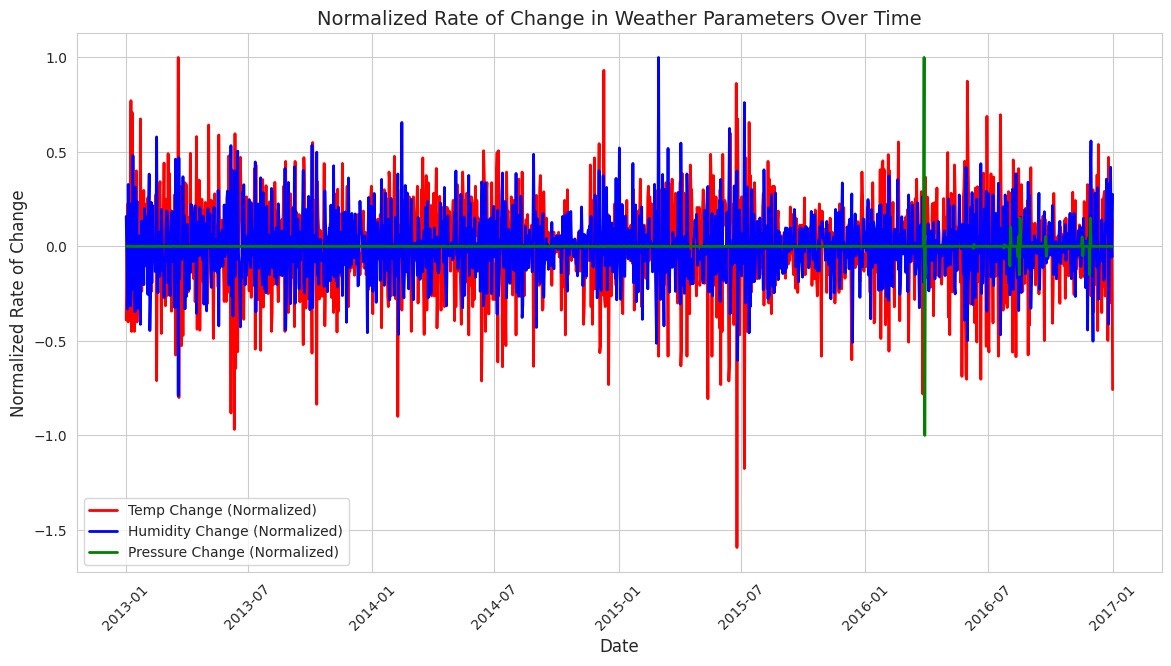

In [31]:
df['temp_rate_of_change'] = df['meantemp'].diff()
df['humidity_rate_of_change'] = df['humidity'].diff()
df['pressure_rate_of_change'] = df['meanpressure'].diff()

df["temp_rate_of_change_norm"] = df["temp_rate_of_change"] / df["temp_rate_of_change"].max()
df["humidity_rate_of_change_norm"] = df["humidity_rate_of_change"] / df["humidity_rate_of_change"].max()
df["pressure_rate_of_change_norm"] = df["pressure_rate_of_change"] / df["pressure_rate_of_change"].max()

plt.figure(figsize=(14,7))

sns.lineplot(x=df["date"], y=df["temp_rate_of_change_norm"], label="Temp Change (Normalized)", color='red', linewidth=2)
sns.lineplot(x=df["date"], y=df["humidity_rate_of_change_norm"], label="Humidity Change (Normalized)", color='blue', linewidth=2)
sns.lineplot(x=df["date"], y=df["pressure_rate_of_change_norm"], label="Pressure Change (Normalized)", color='green', linewidth=2)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Rate of Change", fontsize=12)
plt.title("Normalized Rate of Change in Weather Parameters Over Time", fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.show()



### 8.Creating a plot showing growth factors wrt days to analyse weather trend variation.

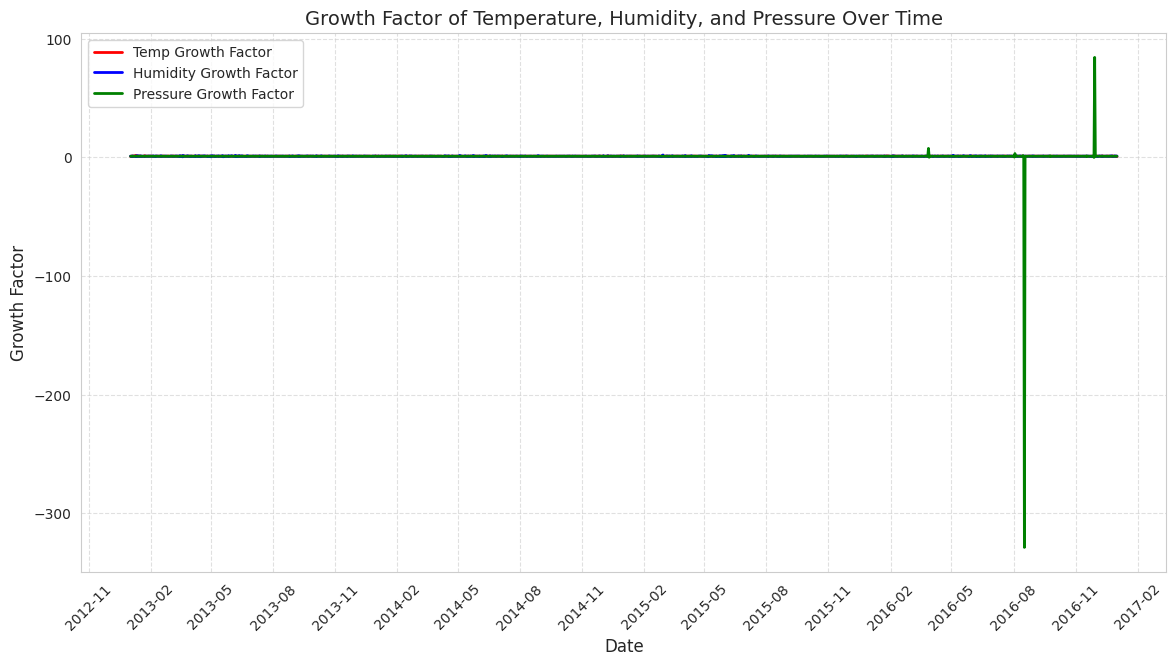

In [32]:
import matplotlib.dates as mdates
df["temp_growth_factor"] = df["meantemp"].pct_change() + 1
df["humidity_growth_factor"] = df["humidity"].pct_change() + 1
df["pressure_growth_factor"] = df["meanpressure"].pct_change() + 1


plt.figure(figsize=(14, 7))

sns.lineplot(x=df["date"], y=df["temp_growth_factor"], label="Temp Growth Factor", color='red', linewidth=2)
sns.lineplot(x=df["date"], y=df["humidity_growth_factor"], label="Humidity Growth Factor", color='blue', linewidth=2)
sns.lineplot(x=df["date"], y=df["pressure_growth_factor"], label="Pressure Growth Factor", color='green', linewidth=2)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Growth Factor", fontsize=12)
plt.title("Growth Factor of Temperature, Humidity, and Pressure Over Time", fontsize=14)
plt.legend()
plt.xticks(rotation=45, fontsize=10)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### 9. Trying different different regression and regularization in the above data.



Linear regression with dates as X-axis

Linear Regression MSE: 35.84846896537246
Linear Regression MAE: 5.1777920108442395


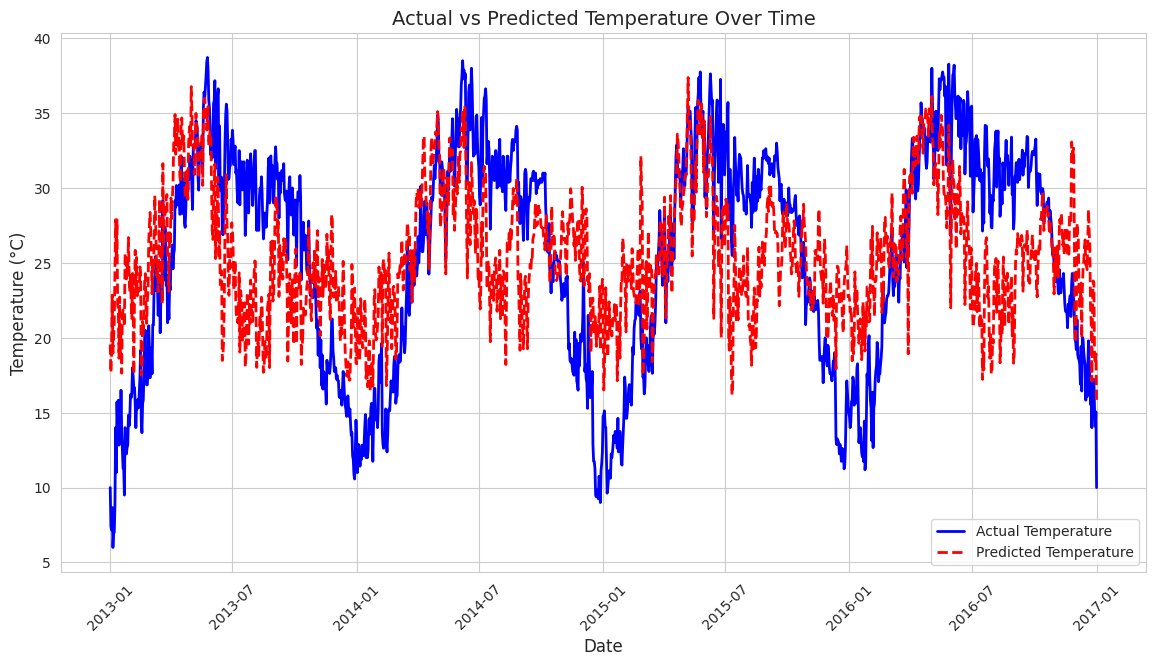

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

X = df[["humidity", "meanpressure"]]
y = df["meantemp"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

df["predicted_temp"] = lin_model.predict(X)

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

plt.plot(df["date"], df["meantemp"], label="Actual Temperature", color="blue", linewidth=2)
plt.plot(df["date"], df["predicted_temp"], label="Predicted Temperature", color="red", linestyle="dashed", linewidth=2)

y_pred_lin = lin_model.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)

print("Linear Regression MSE:", mse_lin)
print("Linear Regression MAE:", mae_lin)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.title("Actual vs Predicted Temperature Over Time", fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.show()


Linear Regression with temparature as X-axis

Linear Regression MSE: 35.84846896537246
Linear Regression MAE: 5.1777920108442395


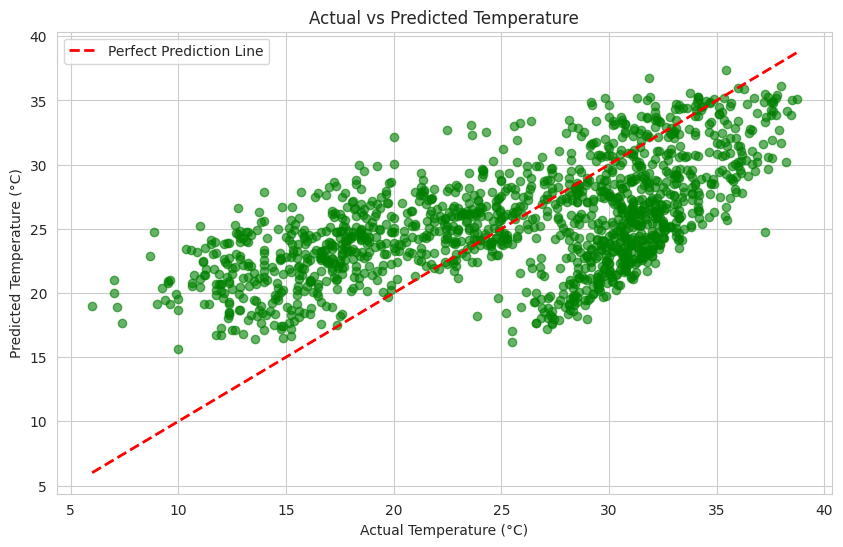

In [42]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.scatter(y, df["predicted_temp"], color="green", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linewidth=2, linestyle="--", label="Perfect Prediction Line")

mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)

print("Linear Regression MSE:", mse_lin)
print("Linear Regression MAE:", mae_lin)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature")
plt.legend()
plt.show()


Polynomial Regression

MAE: 4.992498514527131
MSE: 34.70423625761251


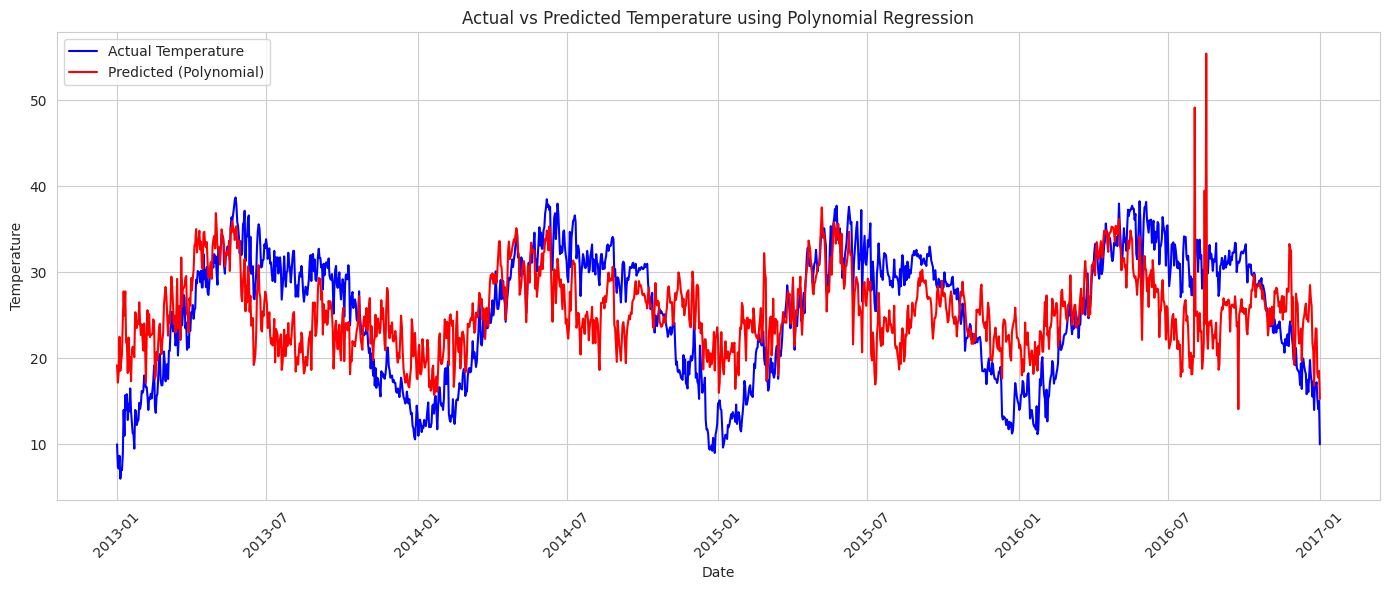

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df[["humidity", "meanpressure"]]
y = df["meantemp"]

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred = poly_model.predict(X_poly)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("MAE:", mae)
print("MSE:", mse)

plt.figure(figsize=(14,6))
plt.plot(df["date"], y, label="Actual Temperature", color="blue")
plt.plot(df["date"], y_pred, label="Predicted (Polynomial)", color="red")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Actual vs Predicted Temperature using Polynomial Regression")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Polynomial Regression with temparature as X-Axis

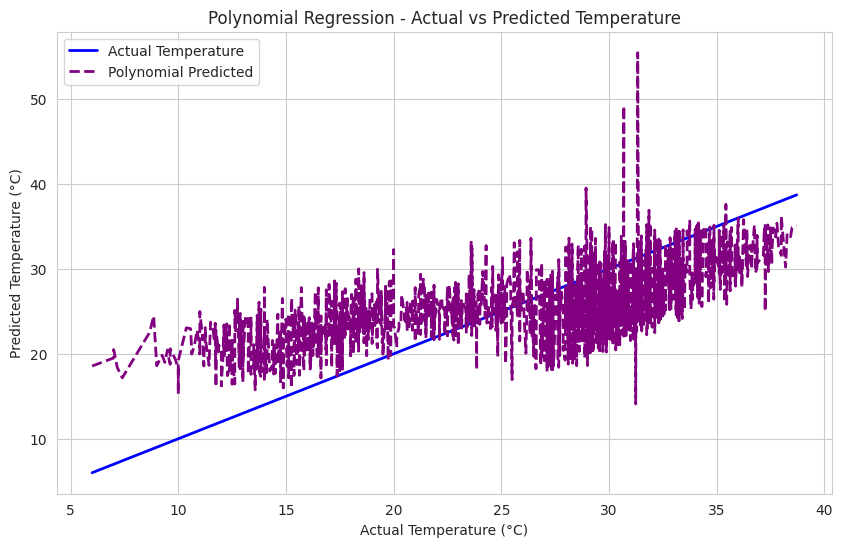

In [36]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

X = df[["humidity", "meanpressure"]]
y = df["meantemp"]

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

poly_predictions = poly_model.predict(X_poly)

df["poly_predicted_temp"] = poly_predictions

sorted_df = df.sort_values(by="meantemp")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.plot(sorted_df["meantemp"], sorted_df["meantemp"], label="Actual Temperature", color="blue", linewidth=2)

plt.plot(sorted_df["meantemp"], sorted_df["poly_predicted_temp"], label="Polynomial Predicted", color="purple", linestyle="dashed", linewidth=2)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Polynomial Regression - Actual vs Predicted Temperature")
plt.legend()
plt.show()



Ridge Regression

MAE: 5.177793447580782
MSE: 35.84846916304338


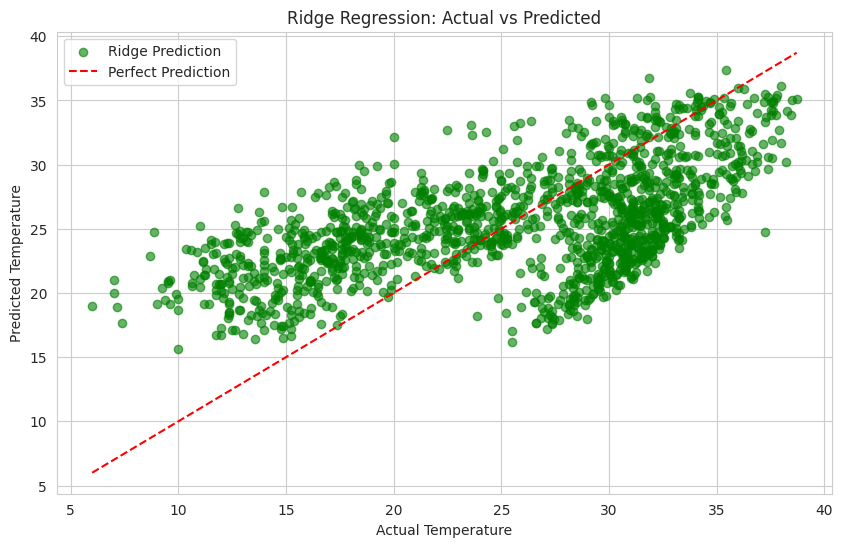

In [37]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

X = df[["humidity", "meanpressure"]]
y = df["meantemp"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

df["ridge_predicted_temp"] = ridge_model.predict(X)
test_ridge_pred = ridge_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, test_ridge_pred))
print("MSE:", mean_squared_error(y_test, test_ridge_pred))


plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.scatter(df["meantemp"], df["ridge_predicted_temp"], color="green", label="Ridge Prediction", alpha=0.6)
plt.plot([df["meantemp"].min(), df["meantemp"].max()],
         [df["meantemp"].min(), df["meantemp"].max()],
         color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Ridge Regression: Actual vs Predicted")
plt.legend()
plt.show()


Polynomial Ridge Regression

In [38]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 1: Split your data
X = df[["humidity", "meanpressure"]]
y = df["meantemp"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Step 2: Create polynomial ridge regression pipeline
poly_ridge_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge(alpha=1.0))  # You can change alpha to control regularization
])

# Step 3: Fit and predict
poly_ridge_model.fit(X_train, y_train)
y_pred = poly_ridge_model.predict(X_test)

# Step 4: Evaluate
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)
plt.show()

Test MSE: 33.71377932004074


/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2)] before, using random point [np.int64(3)]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3)] before, using random point [np.int64(3)]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3)] before, using random point [np.int64(3)]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3)] before, using random point [np.int64(3)]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3)] before, using random point [np.int64(6)]
  warnings.w

Best Degree: 2
Test MSE: 33.714073173698324


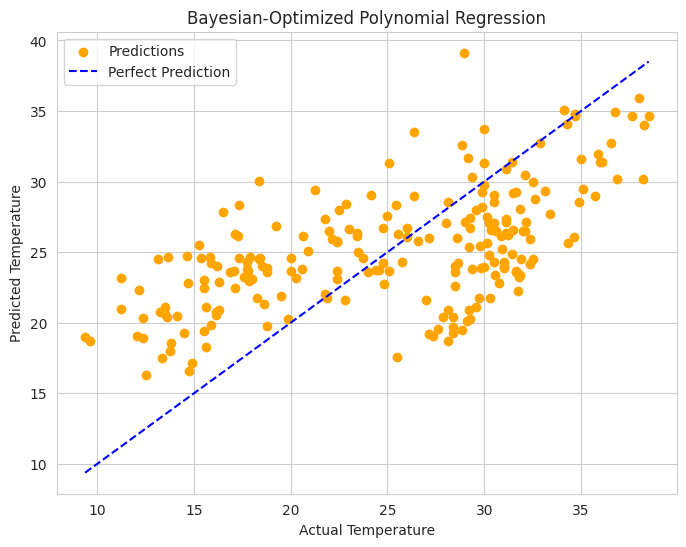

In [39]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Integer
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X = df[["humidity", "meanpressure"]]
y = df["meantemp"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

poly_pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(include_bias=False)),
    ("lin_reg", LinearRegression())
])

param_search = {
    "poly_features__degree": Integer(2, 6)
}

opt = BayesSearchCV(
    estimator=poly_pipeline,
    search_spaces=param_search,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    verbose=0
)

opt.fit(X_train, y_train)

best_model = opt.best_estimator_
test_preds = best_model.predict(X_test)

print("Best Degree:", opt.best_params_["poly_features__degree"])
print("Test MSE:", mean_squared_error(y_test, test_preds))


plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, color="orange", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="blue", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Bayesian-Optimized Polynomial Regression")
plt.legend()
plt.show()

In [47]:
y_pred_lin = lin_model.predict(X_test)
mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
print("\nLinear Regression MSE:", mse_lin)
print("Linear Regression MAE:", mae_lin)

y_pred_poly = poly_model.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)
mae_poly = mean_absolute_error(y, y_pred_poly)
print("\nPolynomial Regression MSE:", mse_poly)
print("Polynomial Regression MAE:", mae_poly)


test_ridge_pred = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, test_ridge_pred)
mae_ridge = mean_absolute_error(y_test, test_ridge_pred)
print("\nRidge Regression MSE:", mse_ridge)
print("Ridge Regression MAE:", mae_ridge)

y_pred_poly_ridge = poly_ridge_model.predict(X_test)
mse_poly_ridge = mean_squared_error(y_test, y_pred_poly_ridge)
mae_poly_ridge = mean_absolute_error(y_test, y_pred_poly_ridge)
print("\nRidge Polynomial Regression MSE:", mse_poly_ridge)
print("Ridge Polynomial Regression MAE:", mae_poly_ridge)



Linear Regression MSE: 35.84846896537246
Linear Regression MAE: 5.1777920108442395

Polynomial Regression MSE: 34.70423625761251
Polynomial Regression MAE: 4.992498514527131

Ridge Regression MSE: 35.84846916304338
Ridge Regression MAE: 5.177793447580782

Ridge Polynomial Regression MSE: 33.71377932004074
Ridge Polynomial Regression MAE: 5.018645562987646


From MSE & MAE we can see that **Ridge Polynomial regression Model** seems to be Best Model